# Function Declarations

Run once

In [41]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

In [42]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

## Plot Confusion Matrix

In [43]:
def plot_confusion_matrix(cm_data, forwhat='', sensible_attribute='', mapping={}):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Weights Functions



### $w_i = 1 + \lambda * Penalty(g_i) $

In [44]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [45]:
def compute_weights_notsized(lambda_=5.0, m='FPN', penalties_onval=None, X_train=None, sensible_attribute=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [46]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [47]:
def compute_weights_sized(lambda_=1.0, m='PPE', penalties_onval=None, X_train=None, sensible_attribute=None):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

---

## Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [48]:
def compute_penalties_after_reweighting(weights, fairness_metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}

    for attribute in attributes:        
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Convert string combinations to numeric codes for XGBoost
        X_train_numeric = X_train[attribute].copy()
        X_train_numeric[attribute] = X_train_numeric[attribute].astype('category').cat.codes
        
        X_test_numeric = X_test[attribute].copy()
        X_test_numeric[attribute] = X_test_numeric[attribute].astype('category').cat.codes
        
        # Train model with weights on combined attribute
        model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_reweighed.fit(X_train_numeric, y_train[attribute], sample_weight=weights)
        
        # Predict on test set
        y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

        cm = confusion_matrix(y_test[attribute], y_pred_test_reweighed_combined, labels=target_variable_labels)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

In [49]:
def performance_after_reweighting(weights, sensible_attribute, X_train, y_train, X_test, y_test): 
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

    perf_metrics = performance_metrics(y_test[sensible_attribute], y_pred_test_reweighed_combined)
    
    return perf_metrics


### Plots

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}, λ: {lambd}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

In [51]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison, λ: {lambd}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

In [52]:
def plot_penalty_comparison_lambdas(fairness_metric, lambdas, penalties_ontest, penalties_after_by_lambda, sensible_attribute, mapping):
    """
    Plot penalty comparison across different lambda values for a single fairness metric.
    
    Args:
        fairness_metric: Single fairness metric to plot (e.g., 'FPN')
        lambdas: List of lambda values
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_after_by_lambda: Dictionary mapping lambda to penalties after reweighting
                                  {lambda: {metric: {subgroup: penalty}}}
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups
    subgroups = list(penalties_ontest[fairness_metric].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Determine grid size based on number of lambdas
    n_lambdas = len(lambdas)
    if n_lambdas <= 3:
        nrows, ncols = 1, n_lambdas
    elif n_lambdas <= 6:
        nrows, ncols = 2, 3
    elif n_lambdas <= 9:
        nrows, ncols = 3, 3
    else:
        nrows, ncols = 3, 4
    
    # Set up the plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
    if n_lambdas == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_lambdas > 1 else [axes]
    
    # Get penalties before reweighting (same for all lambdas)
    penalties_before = [penalties_ontest[fairness_metric].get(group, 0) for group in subgroups]
    
    # Create a bar plot for each lambda
    for idx, lambd in enumerate(lambdas):
        ax = axes[idx]
        
        # Extract penalties after for this lambda
        penalties_after = [penalties_after_by_lambda[lambd][fairness_metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'λ = {lambd}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically
        decoded_labels = []
        for group in subgroups:
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Remove extra subplots if any
    for idx in range(n_lambdas, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison Across Lambda Values\nMetric: {fairness_metric}, Subgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.09)
    plt.show()

In [53]:
def get_distribution_data(df, sensible_attribute, target_variable, mapping):    
    # Step 1: Analyze Subgroup Distribution
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # Load the full dataset
    df_analysis = pd.read_csv(dataset_path)

    # Create combined attribute column
    individual_attrs = sensible_attribute.split('-')
    df_analysis[sensible_attribute] = df_analysis[individual_attrs[0]].astype(str) + df_analysis[individual_attrs[1]].astype(str)

    # print("="*100)
    # print("SUBGROUP DISTRIBUTION ANALYSIS")
    # print("="*100)
    # print(f"\nDataset: {dataset_path}")
    # print(f"Total samples: {len(df_analysis)}")
    # print(f"Sensitive attribute: {sensible_attribute}")
    # print(f"Target variable: {target_variable}")

    # Get all subgroups
    subgroups = sorted(df_analysis[sensible_attribute].unique())

    # Create summary table
    # print("\n" + "-"*100)
    # print(f"{'Subgroup':<12} | {'Decoded':<25} | {'Total':>8} | {'Pos (y=1)':>10} | {'Neg (y=0)':>10} | {'Pos Rate':>10} | {'Balanced?':>10}")
    # print("-"*100)

    distribution_data = []

    for group in subgroups:
        # Decode the group
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        # Get counts
        group_data = df_analysis[df_analysis[sensible_attribute] == group]
        total = len(group_data)
        positive = (group_data[target_variable] == 1).sum()
        negative = (group_data[target_variable] == 0).sum()
        pos_rate = positive / total if total > 0 else 0
        
        # Determine if balanced (within 40-60% range for positive rate)
        balanced = "Yes" if 0.3 <= pos_rate <= 0.7 else "No"
        
        # Check if we can extract 10+10 anchor samples
        can_anchor_10 = "✓" if positive >= 10 and negative >= 10 else "✗"
        
        distribution_data.append({
            'group': group,
            'decoded': decoded,
            'total': total,
            'positive': positive,
            'negative': negative,
            'pos_rate': pos_rate,
            'balanced': balanced,
            'can_anchor_10': can_anchor_10
        })
        
        # print(f"{group:<12} | {decoded:<25} | {total:>8} | {positive:>10} | {negative:>10} | {pos_rate:>9.1%} | {balanced:>10}")

    # print("-"*100)

    # # Summary statistics
    # print("\n" + "="*100)
    # print("FEASIBILITY CHECK: Can we extract anchor samples?")
    # print("="*100)

    # for n_anchor in [5, 10, 15, 20]:
    #     print(f"\n{n_anchor} positive + {n_anchor} negative per subgroup:")
    #     for d in distribution_data:
    #         can = "✓" if d['positive'] >= n_anchor and d['negative'] >= n_anchor else "✗"
    #         shortage_pos = max(0, n_anchor - d['positive'])
    #         shortage_neg = max(0, n_anchor - d['negative'])
    #         status = "OK" if can == "✓" else f"Need +{shortage_pos} pos, +{shortage_neg} neg"
    #         print(f"  {d['group']} ({d['decoded']:18s}): {can} {status}")   
            
    return distribution_data

In [54]:
def plot_subgroup_distribution(distribution_data, sensible_attribute):
    # Visualization: Subgroup Distribution
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Total samples per subgroup
    ax1 = axes[0]
    groups = [d['group'] for d in distribution_data]
    totals = [d['total'] for d in distribution_data]
    decoded_labels = [d['decoded'] for d in distribution_data]

    bars = ax1.bar(groups, totals, color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
    ax1.set_xlabel('Subgroup')
    ax1.set_ylabel('Number of Samples')
    ax1.set_title('Total Samples per Subgroup')
    ax1.set_xticks(range(len(groups)))
    ax1.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)

    # Add value labels on bars
    for bar, total in zip(bars, totals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{total:,}', ha='center', va='bottom', fontsize=10)

    # Plot 2: Positive vs Negative per subgroup (stacked)
    ax2 = axes[1]
    positives = [d['positive'] for d in distribution_data]
    negatives = [d['negative'] for d in distribution_data]

    x = np.arange(len(groups))
    width = 0.6

    bars_neg = ax2.bar(x, negatives, width, label='Negative (y=0)', color='#3498db')
    bars_pos = ax2.bar(x, positives, width, bottom=negatives, label='Positive (y=1)', color='#e74c3c')

    ax2.set_xlabel('Subgroup')
    ax2.set_ylabel('Number of Samples')
    ax2.set_title('Positive vs Negative Labels per Subgroup')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
    ax2.legend()

    # Plot 3: Positive rate per subgroup
    ax3 = axes[2]
    pos_rates = [d['pos_rate'] * 100 for d in distribution_data]

    bars = ax3.bar(groups, pos_rates, color=['#2ecc71' if 30 <= r <= 70 else '#e74c3c' for r in pos_rates])
    ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Balanced (50%)')
    ax3.axhline(y=30, color='gray', linestyle=':', linewidth=1)
    ax3.axhline(y=70, color='gray', linestyle=':', linewidth=1)
    ax3.set_xlabel('Subgroup')
    ax3.set_ylabel('Positive Rate (%)')
    ax3.set_title('Class Balance per Subgroup')
    ax3.set_xticks(range(len(groups)))
    ax3.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
    ax3.set_ylim(0, 100)
    ax3.legend()

    # Add value labels
    for bar, rate in zip(bars, pos_rates):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.suptitle(f'Distribution Analysis: {sensible_attribute}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [55]:
from sklearn.model_selection import StratifiedKFold, KFold
import xgboost as xgb

def compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5, verbose=True):
    """
    Compute penalties using K-Fold cross-validation for more stable estimates.
    
    Args:
        sensible_attribute: Combined attribute like 'sex-race'
        fair_metrics: List of fairness metrics to compute penalties for
        n_folds: Number of folds (default 5)
        verbose: Print progress
    
    Returns:
        penalties_kfold_avg: Dict of {metric: {subgroup: averaged_penalty}}
        penalties_per_fold: Dict of {metric: {subgroup: [penalties_per_fold]}}
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*80)
        print(f"K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K={n_folds})")
        print("="*80)
        print(f"Train+Val samples: {len(X_trainval)}")
        print(f"Test samples (held out): {len(X_test[sensible_attribute])}")
    
    # Initialize storage for penalties per fold
    penalties_per_fold = {m: {g: [] for g in ['00', '01', '10', '11']} for m in fair_metrics}

    # Setup stratified K-fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Load dataframe once for fairness computation
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Split data for this fold
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        if verbose:
            # Show distribution in this fold's validation set
            val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
            print(f"  Val distribution: {val_dist.to_dict()}")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes

        # X_fold_train_num = X_fold_train.copy()
        # X_fold_val_num   = X_fold_val.copy()

        # cats = pd.Index(X_fold_train[sensible_attribute].astype(str).unique()).sort_values()
        # cat2code = {c: i for i, c in enumerate(cats)}

        # X_fold_train_num[sensible_attribute] = (
        #     X_fold_train[sensible_attribute].astype(str).map(cat2code).astype(int)
        # )
        # X_fold_val_num[sensible_attribute] = (
        #     X_fold_val[sensible_attribute].astype(str).map(cat2code).fillna(-1).astype(int)
        # )

        
        # Train model on this fold's training data
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on this fold's validation data
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            # Get sensible indexes for this fold's validation set
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            # Compute confusion matrix
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            # Compute fairness metrics
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties for each metric
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            # Store penalty for each subgroup
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in ['00', '01', '10', '11']:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*80)
        print("AVERAGED PENALTIES (across 5 folds)")
        print("="*80)
        for m in fair_metrics[:3]:  # Show first 3 metrics
            print(f"\n{m}:")
            for group in ['00', '01', '10', '11']:
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                fold_vals = penalties_per_fold[m][group]
                print(f"  {group}: avg={avg:+.2f}%, std={std:.2f}, folds={[f'{v:.1f}' for v in fold_vals]}")
    
    return penalties_kfold_avg, penalties_per_fold

In [56]:
def compute_weights_kfold(lambda_=5.0, m='PPE'):
    """
    Compute weights using K-fold averaged penalties instead of single-split penalties.
    """
    # Combine train + val for final training
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    weights_for_training = np.ones(len(X_trainval))
    
    # Use K-fold averaged penalties
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_kfold_avg[m].items()
    }
    
    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(X_trainval.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    print(f"Training samples: {len(weights_for_training)}, Weights per group (K-fold): {group_weights}")
    
    return weights_for_training, X_trainval, y_trainval

In [57]:
def compute_penalties_after_reweighting_kfold(weights, X_trainval, y_trainval, fairness_metric, dataset_path, sensible_attribute, X_test, y_test, fair_metrics, mapping, target_variable_labels):
    """
    Train model on FULL train+val data with K-fold weights, evaluate on test set.
    """
    # Convert to numeric for XGBoost
    X_trainval_num = X_trainval.copy()
    X_trainval_num[sensible_attribute] = X_trainval_num[sensible_attribute].astype('category').cat.codes
    
    X_test_num = X_test[sensible_attribute].copy()
    X_test_num[sensible_attribute] = X_test_num[sensible_attribute].astype('category').cat.codes
    
    # Train model on full train+val with weights
    model_kfold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_kfold.fit(X_trainval_num, y_trainval, sample_weight=weights)
    
    # Predict on test set
    y_pred_test_kfold = model_kfold.predict(X_test_num)
    
    # Compute fairness metrics
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    df_fresh = pd.read_csv(dataset_path)
    
    fairness_metrics_kfold = {}
    
    for attribute in attributes:
        df_attr = df_fresh.copy()
        
        if '-' in attribute:
            indiv_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str),
                [df_attr[col] for col in indiv_attrs]
            )
        
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_test_kfold, y_test[sensible_attribute], X_test[sensible_attribute],
            target_variable_labels
        )
        
        fairness_metrics_kfold[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_kfold[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    harmonic, _, _ = compute_penalty_2(
        fairness_metrics_kfold, df_fresh,
        individual_attrs[0], individual_attrs[1],
        fairness_metric
    )
    
    return harmonic

# Experiment Runs

# ADULT CENSUS

## Parameters

Made so they can be easily changed

In [58]:
# Flags
ALL_FM_L_NOTSIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using notsized weights
SIZED = 0 # Set to 1 to add plots using sized weights
ALL_FM_L_SIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using sized weights

In [59]:
datasets = {0: 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv', 
            1: '/COMPAS/compas-preprocessed-binary.csv', 
            2: '/GermanCredit/german-preprocessed-binary.csv'}

dataset_path = datasets[0]

In [60]:
sensible_attribute = 'sex-race'

In [61]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

models = {
    'xgb': xgb.XGBClassifier(random_state=1234, eval_metric='logloss'),
    'lgbm': lgb.LGBMClassifier(random_state=1234, verbose=-1),
    'cb': cb.CatBoostClassifier(random_state=1234, verbose=False)
  }

selected_model = models['xgb']

In [62]:
# ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
fair_metrics = ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']

In [63]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

In [64]:
fixed_lambda = 5.0

In [65]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


In [66]:
import pandas as pd

df=pd.read_csv(dataset_path)

if dataset_path == datasets[0]:  # Adult Census
    protected_attributes =['age', 'sex', 'race', 'edu']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'edu':{
            0: 'low-edu',
            1: 'high-edu'
        },
        'sex':{
            0: 'female',
            1: 'male'
        },
        'race':{
            0: 'Amer-Black-Other',
            1: 'Asian-White'
        }
    }
    feature_cols= df.columns
    target_variable = 'income'
elif dataset_path == datasets[1]:  # COMPAS
    protected_attributes =['age', 'sex', 'race']
    mapping= {
        'age':{
            0: 'age<35',
            1: 'age>35',
        },
        'sex':{
            0: 'fem',
            1: 'mal'
        },
        'race':{
            0: 'African',
            1: 'AsiaWhiHispNatOth'
        }
    }
    feature_cols= df.columns
    target_variable = 'is_violent_recid'
elif dataset_path == datasets[2]:  # German Credit
    protected_attributes =['age', 'sex']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'sex':{
            0: 'female',
            1: 'male'
        }
    }
    feature_cols= df.columns
    target_variable = 'risk'

target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [67]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}
performance_metrics_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}
performance_metrics_test = {}

for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set | Model 1A
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute], performance_metrics_val[attribute] = \
    compute_model_predictions_general(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], \
                              target_variable_labels, attribute, selected_model)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set | Model 1B
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute], performance_metrics_test[attribute] = \
    compute_model_predictions_general(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], \
                                      target_variable_labels, attribute, selected_model)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7556935817805382, Recall: 0.6108786610878661, Accuracy: 0.8564701064701065, F1: 0.6756131420638594
{np.int64(0): array([[1448,   20],
       [  87,   94]]), np.int64(1): array([[2005,  216],
       [ 378,  636]])}
sex
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
race
Precision: 0.7556935817805382, Recall: 0.6108786610878661, Accuracy: 0.8564701064701065, F1: 0.6756131420638594
{np.int64(1): array([[2983,  228],
       [ 428,  701]]), np.int64(0): array([[470,   8],
       [ 37,  29]])}
race
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109
{np.int64(1): array([[2966,  219],
       [ 377,  753]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
sex-race
Precision: 0.7559958289885297, Recall: 0.606694560669456, Accuracy: 0.855

In [68]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

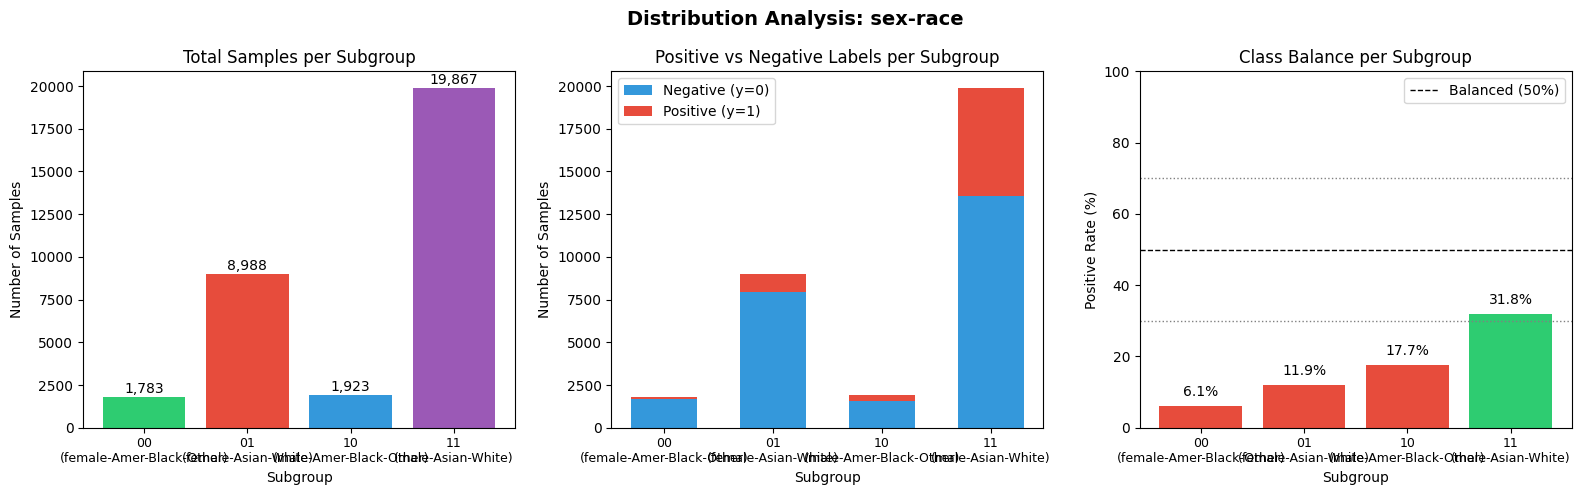

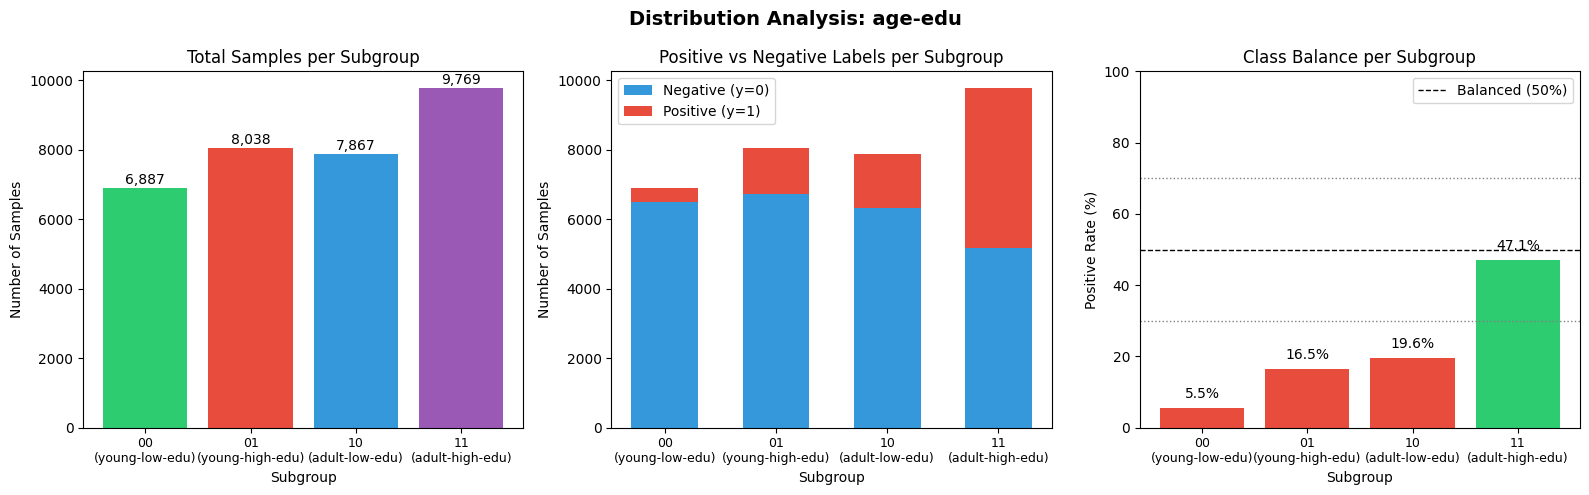

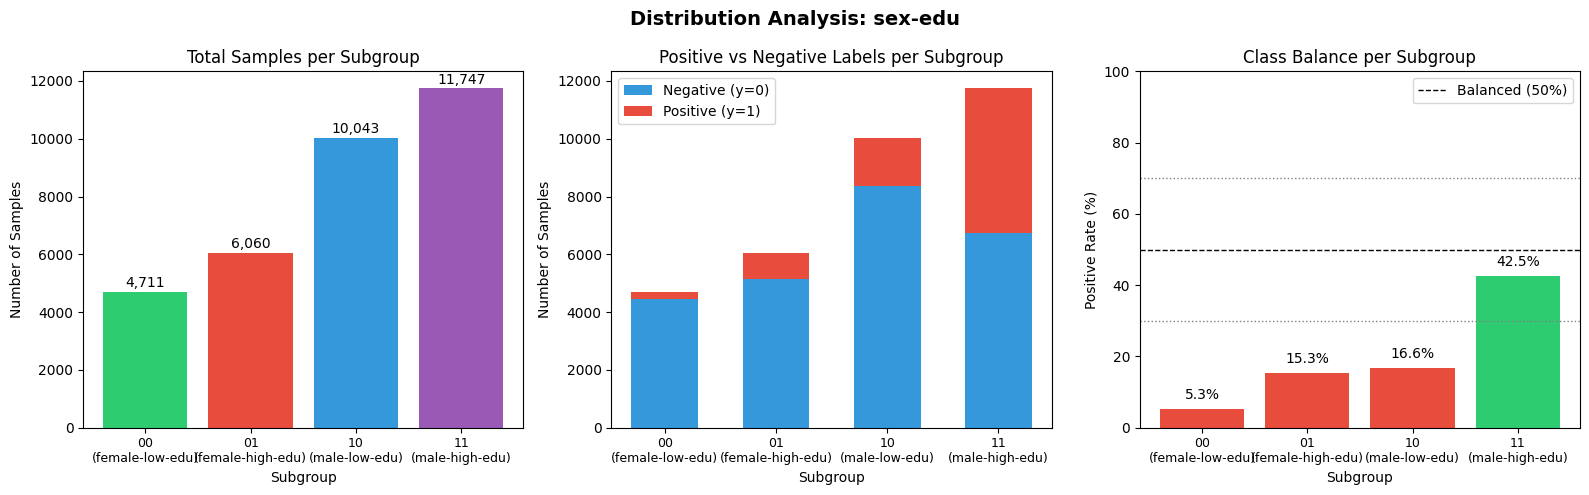

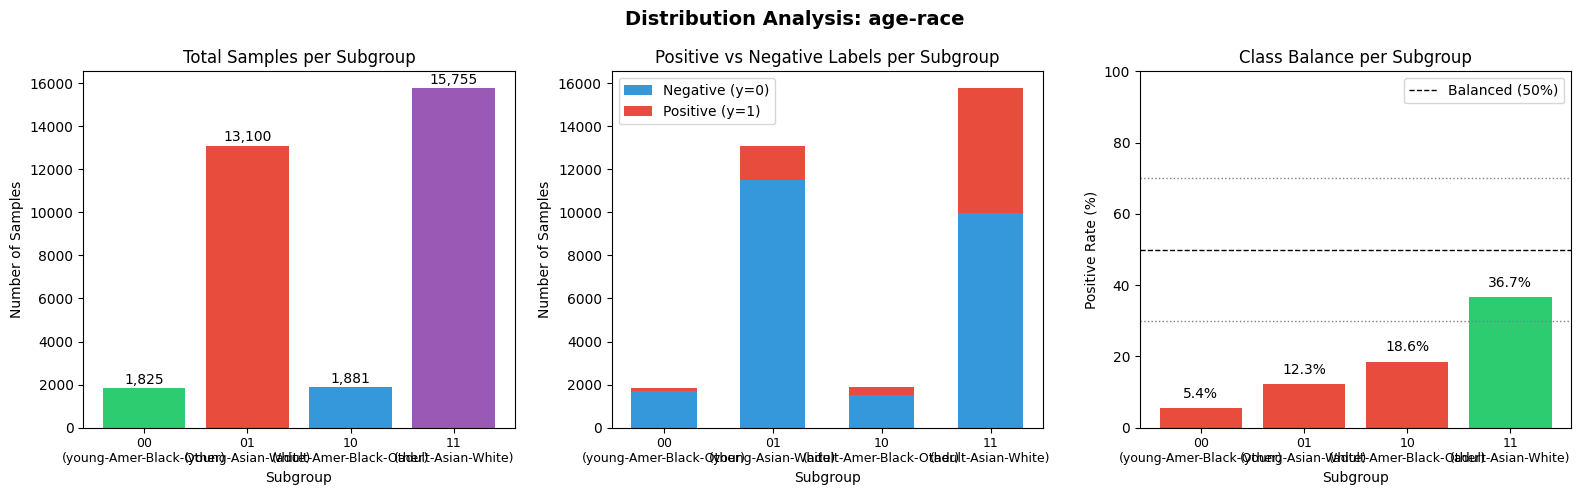

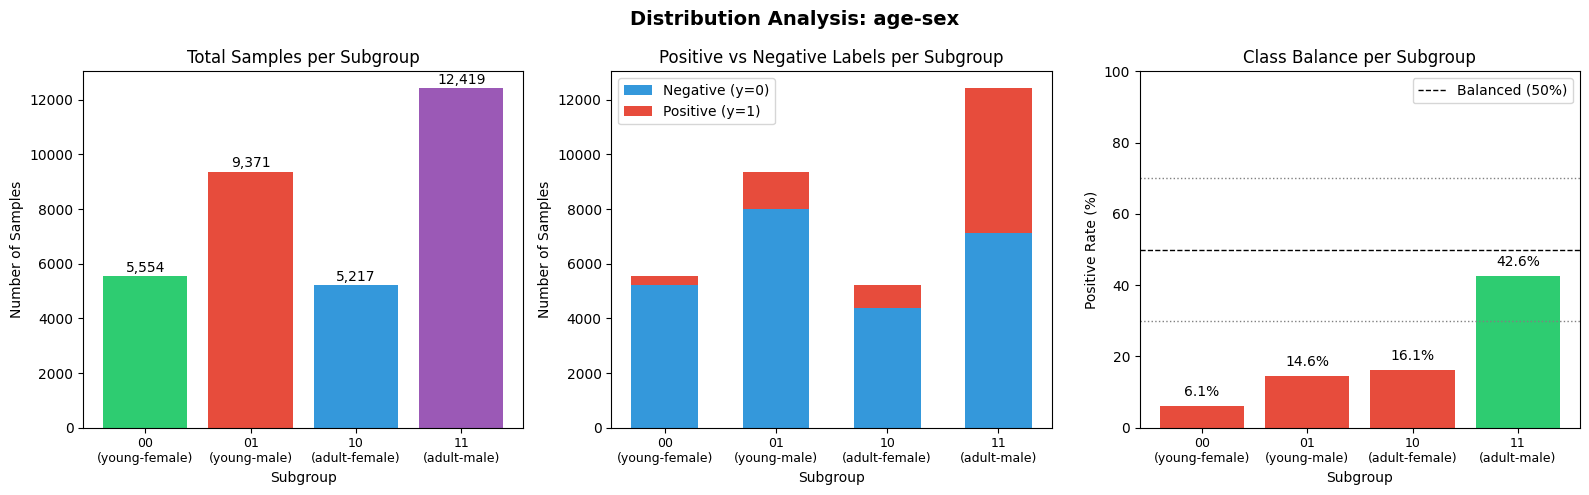

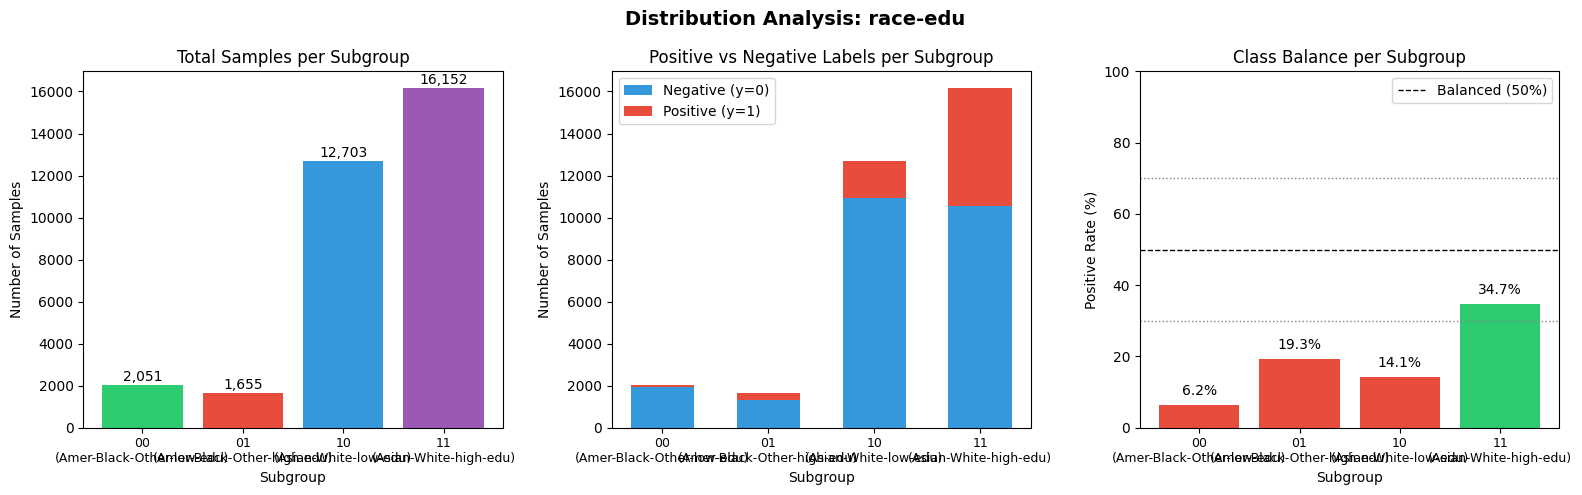

In [69]:
subgroups = ['sex-race', 'age-edu', 'sex-edu', 'age-race', 'age-sex', 'race-edu']
for subgroup in subgroups:
    df = prepare_dataframe_for_attribute(dataset_path, subgroup)
    distribution_data = get_distribution_data(df, subgroup, target_variable, mapping)
    plot_subgroup_distribution(distribution_data, subgroup)

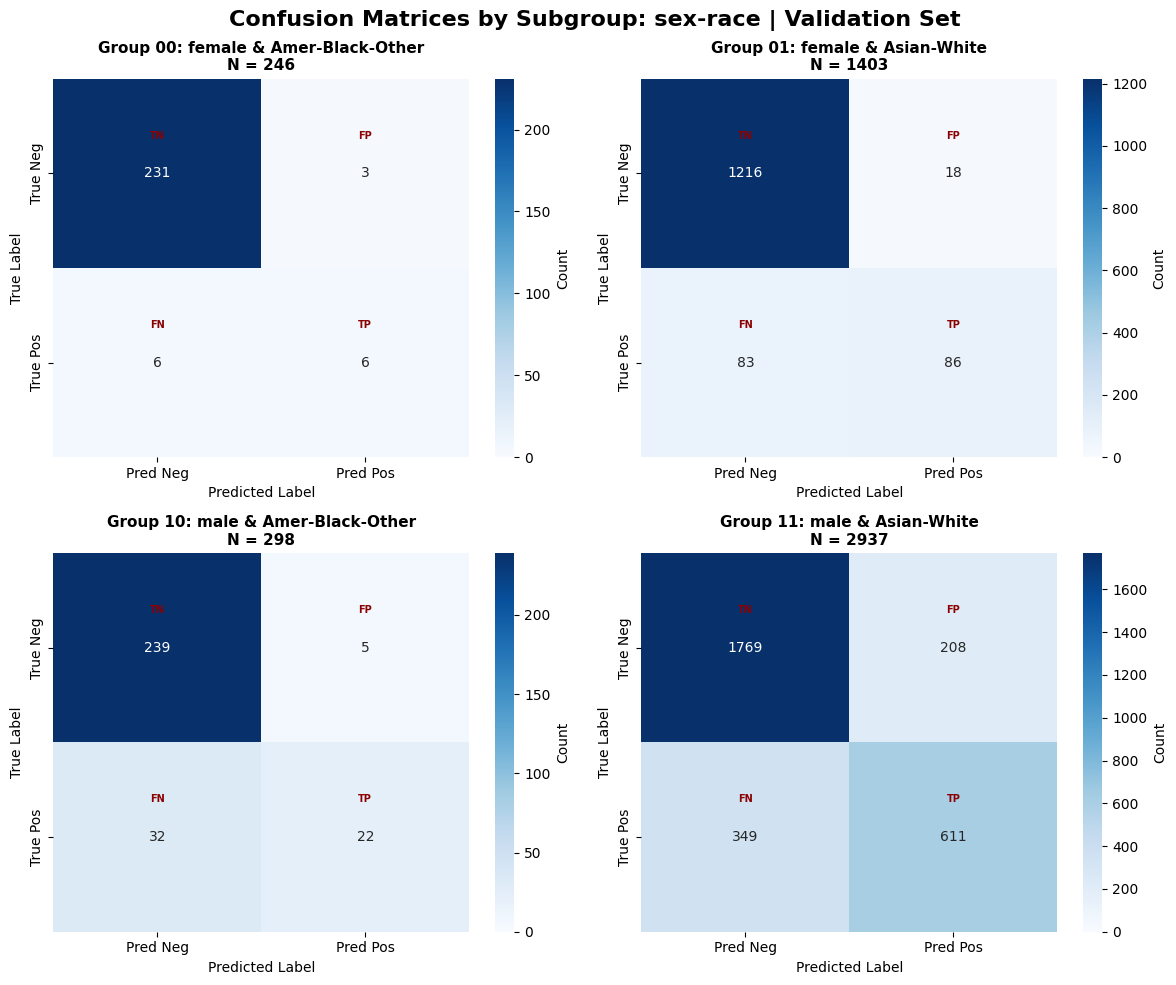

In [70]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set', sensible_attribute, mapping)

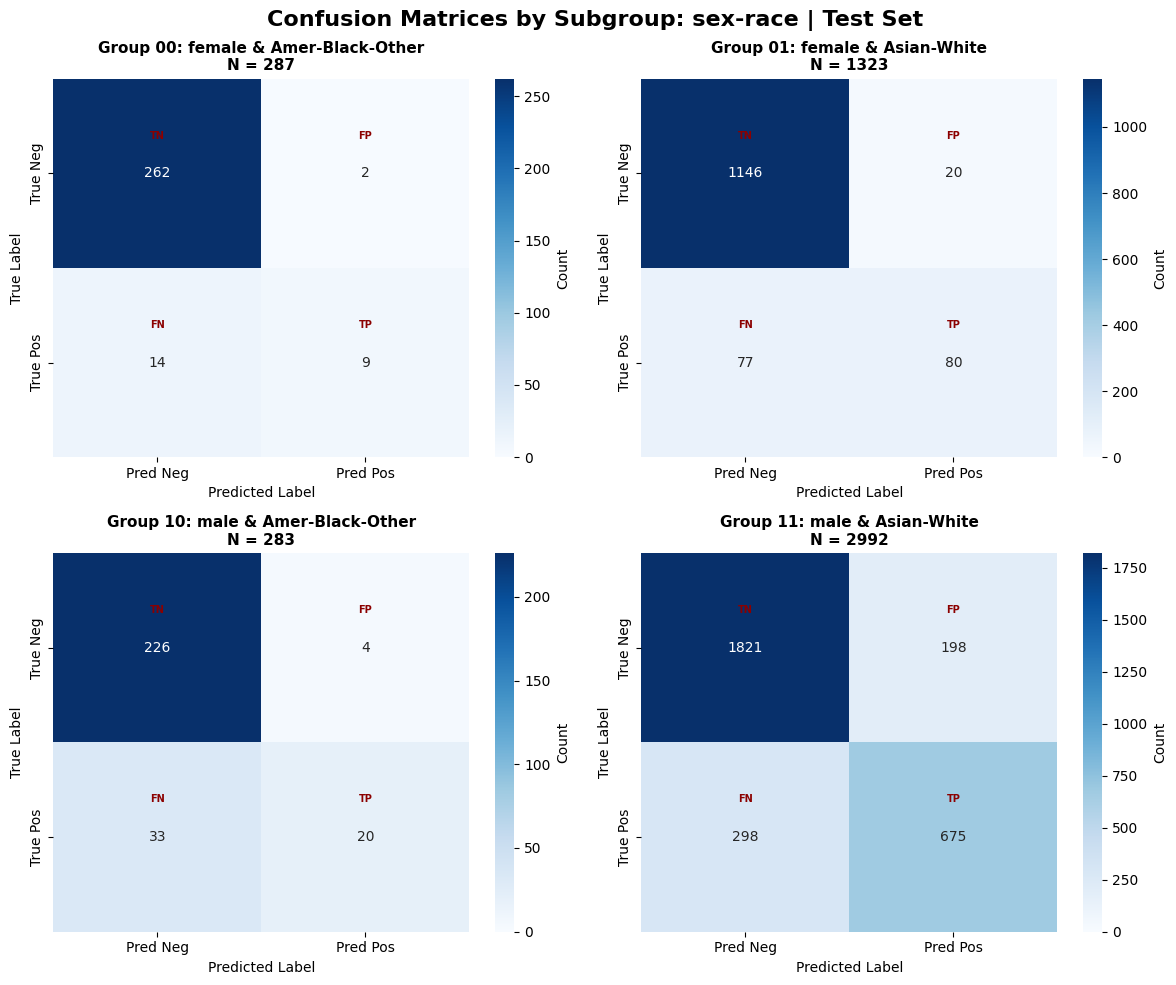

In [71]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set', sensible_attribute, mapping)

In [72]:
weights_notsized = compute_weights_notsized(fixed_lambda, 'FPN', penalties_onval, X_train, sensible_attribute)
performance_metrics_after = performance_after_reweighting(weights_notsized, sensible_attribute, X_train, y_train, X_test, y_test)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
Precision: 0.7777777777777778, Recall: 0.6500829187396352, Accuracy: 0.8677584442169908, F1: 0.7082204155374887


Observation: performance remains stable (in some cases even better). For higher lambdas (>20), the performance starts to drop. 

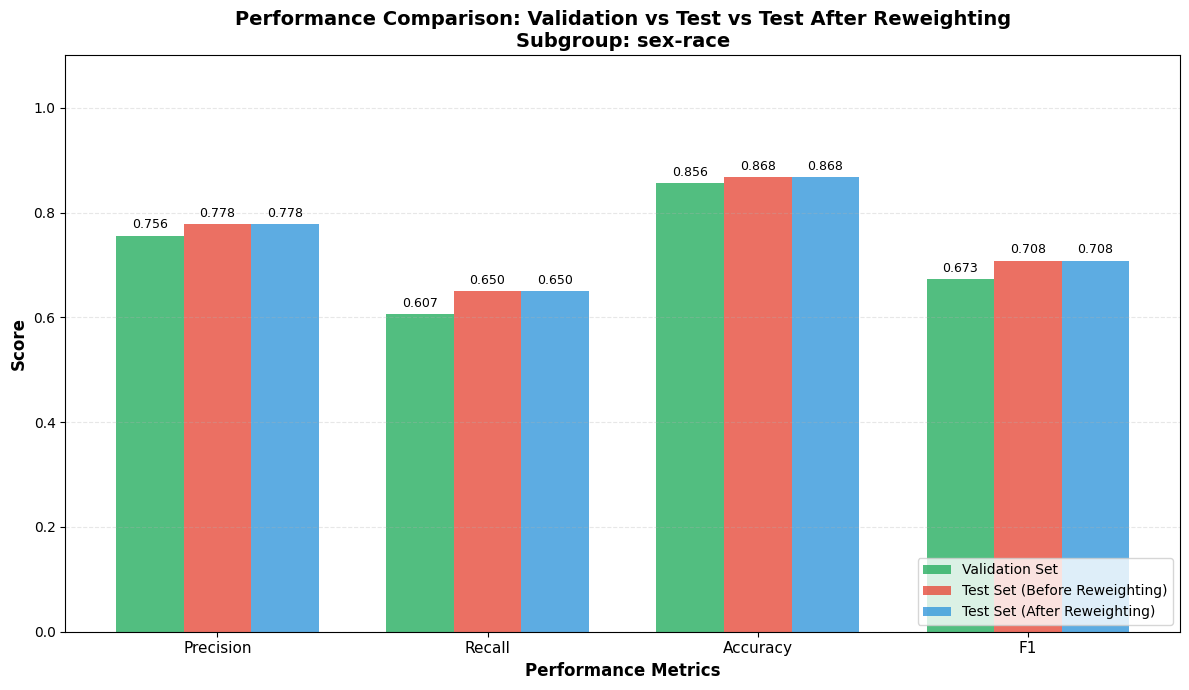


Performance Metrics Comparison:
Metric          Validation      Test (Before)   Test (After)    Δ (After-Before)
--------------------------------------------------------------------------------
Precision       0.7560          0.7778          0.7778          +0.0000
Recall          0.6067          0.6501          0.6501          +0.0000
Accuracy        0.8559          0.8678          0.8678          +0.0000
F1              0.6732          0.7082          0.7082          +0.0000


In [73]:
# Plot performance comparison
plot_performance_comparison(performance_metrics_val, performance_metrics_test, performance_metrics_after, sensible_attribute)

---

# Penalty After Reweighting Plots

### Utils

In [74]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2043,  206],
       [ 328,  698]])}
{np.int64(1): array([[2965,  220],
       [ 371,  759]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1145,   21],
       [  74,   83]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1825,  194],
       [ 304,  669]]), '10': array([[224,   6],
       [ 31,  22]])}
Training samples: 22792, Unique weights per group: {'00': 1.7323717948717945, '01': 2.809764991896272, '10': 2.4122742106860953, '11': 0.01}
{np.int64(0): array([[1406,   24],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 382,  644]])}
{np.int64(1): array([[2971,  214],
       [ 437,  693]]), np.int64(0): array([[479,  15],
       [ 33,  43]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[262,   2

## Penalty before and after reweighting

In [75]:
def create_penalty_comparison_table(penalties_before, penalties_after, sensible_attribute, mapping, metrics_to_show=None):
    """
    Create a comprehensive table comparing penalties before and after reweighting.
    
    Args:
        penalties_before: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_after: Dictionary of penalties after reweighting {metric: {subgroup: penalty}}
        sensible_attribute: Combined attribute string (e.g., 'sex-race')
        mapping: Dictionary mapping attribute codes to labels
        metrics_to_show: List of metrics to display (None = all metrics)
    
    Returns:
        DataFrame with comparison statistics
    """
    import pandas as pd
    
    # If no specific metrics requested, show all
    if metrics_to_show is None:
        metrics_to_show = list(penalties_before.keys())
    
    # Parse individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Collect data for table
    table_data = []
    
    for metric in metrics_to_show:
        if metric not in penalties_before or metric not in penalties_after:
            continue
            
        for subgroup in penalties_before[metric].keys():
            before = penalties_before[metric][subgroup]
            after = penalties_after[metric][subgroup]
            diff = after - before
            
            # Calculate percentage reduction
            if before != 0:
                pct_reduction = ((before - after) / abs(before)) * 100
            else:
                pct_reduction = 0
            
            # Decode subgroup label
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(subgroup[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_label = '-'.join(decoded_parts)
            
            table_data.append({
                'Metric': metric,
                'Subgroup': decoded_label,
                'Before': f"{before:.2f}",
                'After': f"{after:.2f}",
                'Difference': f"{diff:+.2f}",
                'Reduction (%)': f"{pct_reduction:.1f}%"
            })
    
    df = pd.DataFrame(table_data)
    return df

In [76]:
# Create comprehensive comparison table for all metrics
df_comparison = create_penalty_comparison_table(
    penalties_ontest, 
    penalties_ontest_after_reweighting, 
    sensible_attribute, 
    mapping
)

print("\n" + "="*100)
print(f"PENALTY COMPARISON: BEFORE vs AFTER REWEIGHTING (λ={fixed_lambda})")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Also create a focused table for key metrics
print("\n\nKEY METRICS SUMMARY")
print("="*100)
key_metrics = ['FPN', 'PPE', 'EOP']
df_key = create_penalty_comparison_table(
    penalties_ontest, 
    penalties_ontest_after_reweighting, 
    sensible_attribute, 
    mapping,
    metrics_to_show=key_metrics
)
print(df_key.to_string(index=False))
print("="*100)


PENALTY COMPARISON: BEFORE vs AFTER REWEIGHTING (λ=5.0)
Metric                Subgroup Before  After Difference Reduction (%)
   FPN female-Amer-Black-Other  25.71 -10.58     -36.29        141.2%
   FPN      female-Asian-White  18.99  14.54      -4.45         23.4%
   FPN   male-Amer-Black-Other  49.35  24.25     -25.10         50.9%
   FPN        male-Asian-White  -6.60  -2.82      +3.79        -57.4%
   PPE female-Amer-Black-Other  51.99  64.96     +12.97        -24.9%
   PPE      female-Asian-White  31.78  36.14      +4.35        -13.7%
   PPE   male-Amer-Black-Other  36.76 -24.08     -60.84        165.5%
   PPE        male-Asian-White -25.11 -33.82      -8.71         34.7%
   GFA female-Amer-Black-Other  43.46  39.37      -4.09          9.4%
   GFA      female-Asian-White  28.41  26.83      -1.58          5.6%
   GFA   male-Amer-Black-Other  20.95 -54.94     -75.89        362.3%
   GFA        male-Asian-White -17.91 -19.64      -1.73          9.6%
   PPA female-Amer-Black-Other  -

In [77]:
# Summary statistics per metric (averaged across subgroups)
print("\n\nSUMMARY: AVERAGE PENALTY REDUCTION BY METRIC")
print("="*80)

summary_data = []
for metric in fair_metrics:
    if metric in penalties_ontest and metric in penalties_ontest_after_reweighting:
        before_values = list(penalties_ontest[metric].values())
        after_values = list(penalties_ontest_after_reweighting[metric].values())
        
        avg_before = np.mean(before_values)
        avg_after = np.mean(after_values)
        avg_reduction = avg_before - avg_after
        pct_reduction = (avg_reduction / abs(avg_before)) * 100 if avg_before != 0 else 0
        
        summary_data.append({
            'Metric': metric,
            'Avg Before': f"{avg_before:.2f}",
            'Avg After': f"{avg_after:.2f}",
            'Avg Reduction': f"{avg_reduction:.2f}",
            'Reduction (%)': f"{pct_reduction:.1f}%"
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print("="*80)



SUMMARY: AVERAGE PENALTY REDUCTION BY METRIC
Metric Avg Before Avg After Avg Reduction Reduction (%)
   FPN      21.86      6.35         15.51         71.0%
   PPE      23.86     10.80         13.06         54.7%
   GFA      18.73     -2.10         20.82        111.2%
   PPA      -2.77     -1.58         -1.19        -43.0%
   OAE      -1.20     -1.24          0.04          3.4%
   FPR       9.98     -7.91         17.89        179.2%
   FPA       4.29     14.09         -9.80       -228.2%
   EOP     -18.34    -14.98         -3.36        -18.3%
   FNP       1.49     15.81        -14.32       -962.9%
   FPP      24.94     10.45         14.49         58.1%


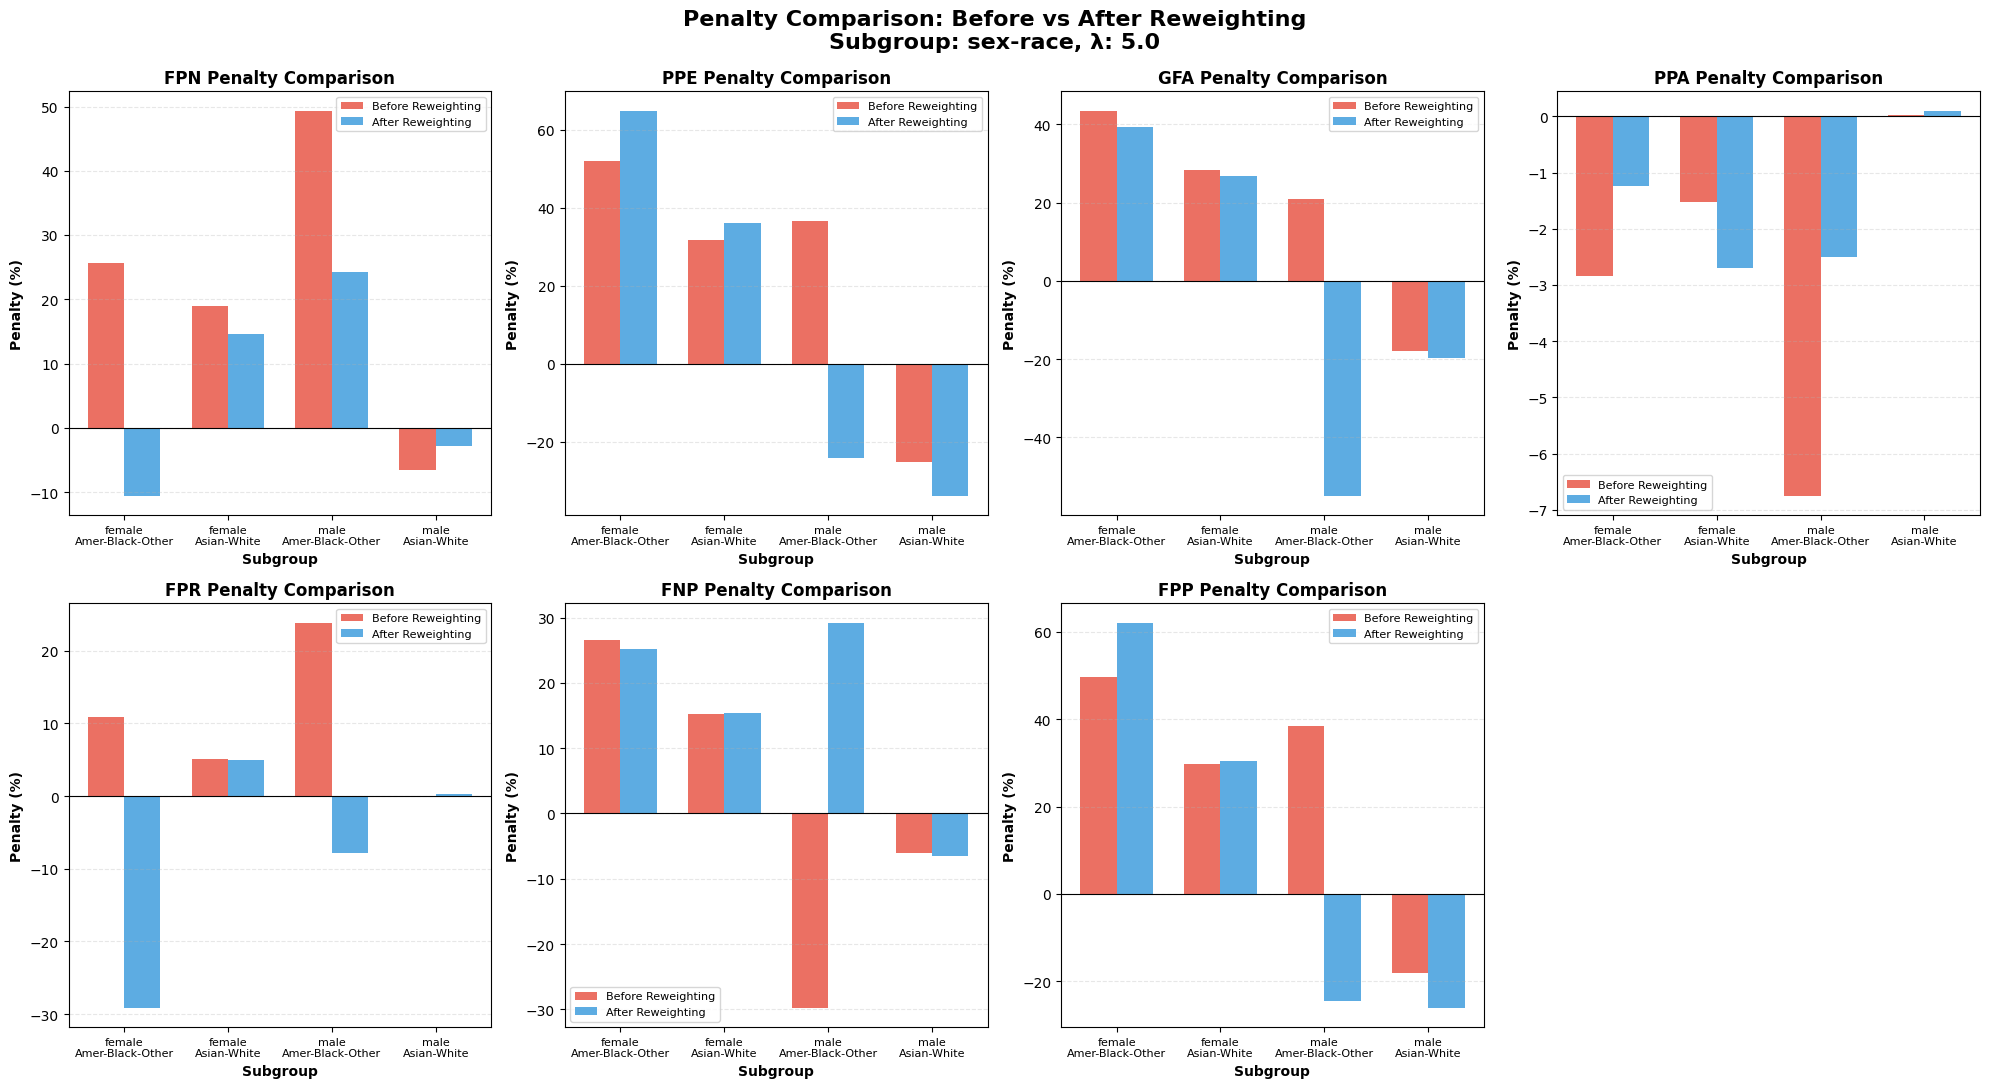

In [78]:
# Use as many fairness metrics as needed
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping, fixed_lambda)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2043,  206],
       [ 328,  698]])}
{np.int64(1): array([[2965,  220],
       [ 371,  759]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1145,   21],
       [  74,   83]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1825,  194],
       [ 304,  669]]), '10': array([[224,   6],
       [ 31,  22]])}


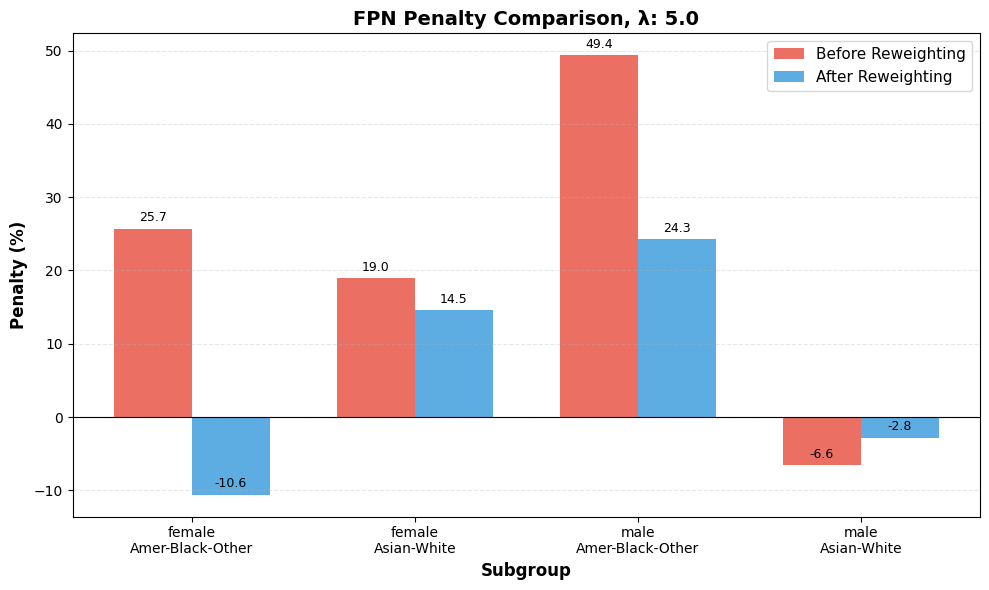


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → -10.58 (Δ = -36.29)
  female-Asian-White: 18.99 → 14.54 (Δ = -4.45)
  male-Amer-Black-Other: 49.35 → 24.25 (Δ = -25.10)
  male-Asian-White: -6.60 → -2.82 (Δ = +3.79)
------------------------------------------------------------


In [79]:
metrics = ['FPN']
penalties_ontest_after_reweighting = {}
for metric in metrics:
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

plot_penalty_comparison_all_individual(metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, fixed_lambda)

Training samples: 22792, Unique weights per group: {'00': 0.5854166666666667, '01': 1.1334418968212612, '10': 1.2170608108108107, '11': 0.9746606192321018}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2047,  202],
       [ 334,  692]])}
{np.int64(1): array([[2967,  218],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 46,  30]])}
{'01': array([[1136,   30],
       [  71,   86]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1812,  207],
       [ 286,  687]]), '10': array([[225,   5],
       [ 33,  20]])}


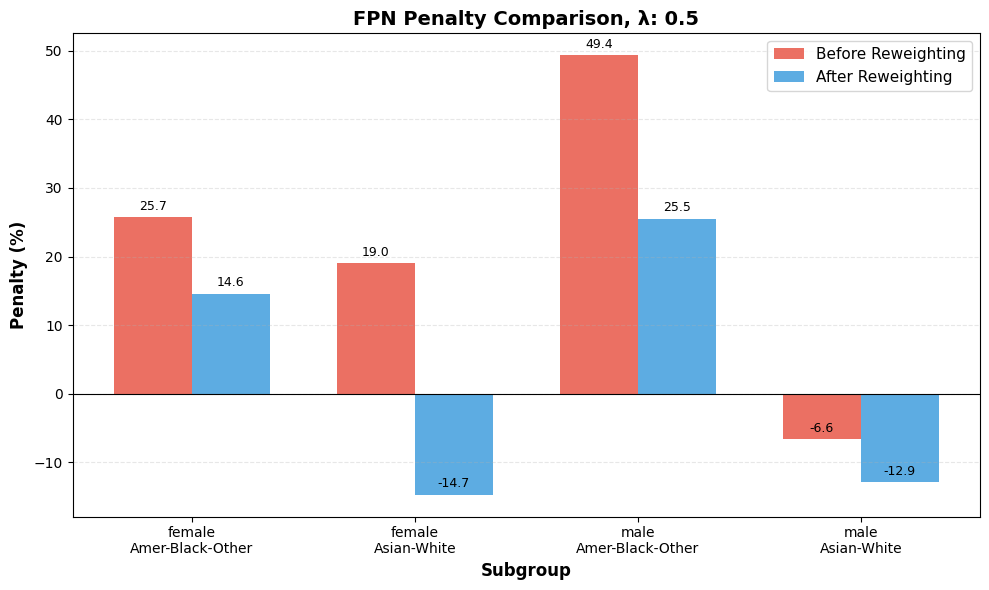


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 14.58 (Δ = -11.13)
  female-Asian-White: 18.99 → -14.72 (Δ = -33.72)
  male-Amer-Black-Other: 49.35 → 25.53 (Δ = -23.83)
  male-Asian-White: -6.60 → -12.91 (Δ = -6.31)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.17083333333333328, '01': 1.2668837936425221, '10': 1.4341216216216215, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2045,  204],
       [ 332,  694]])}
{np.int64(1): array([[2965,  220],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1819,  200],
       [ 301,  672]]), '10': array([[225,   5],
       [ 33,  20]])}


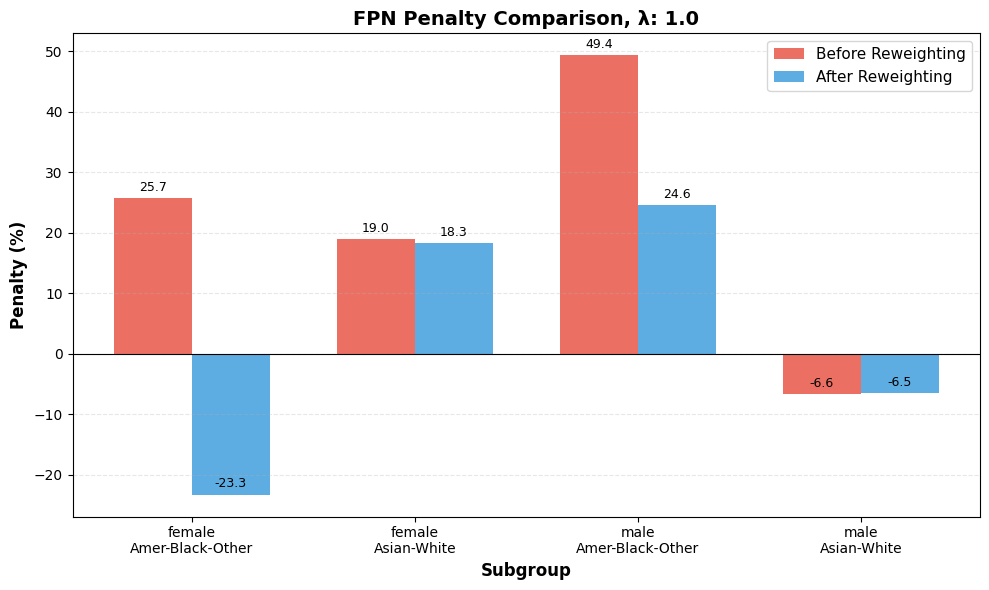


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → -23.26 (Δ = -48.97)
  female-Asian-White: 18.99 → 18.28 (Δ = -0.71)
  male-Amer-Black-Other: 49.35 → 24.60 (Δ = -24.75)
  male-Asian-White: -6.60 → -6.52 (Δ = +0.09)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 1.5337675872850443, '10': 1.868243243243243, '11': 0.8986424769284072}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2044,  205],
       [ 331,  695]])}
{np.int64(1): array([[2967,  218],
       [ 375,  755]]), np.int64(0): array([[485,   9],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1823,  196],
       [ 299,  674]]), '10': array([[226,   4],
       [ 32,  21]])}


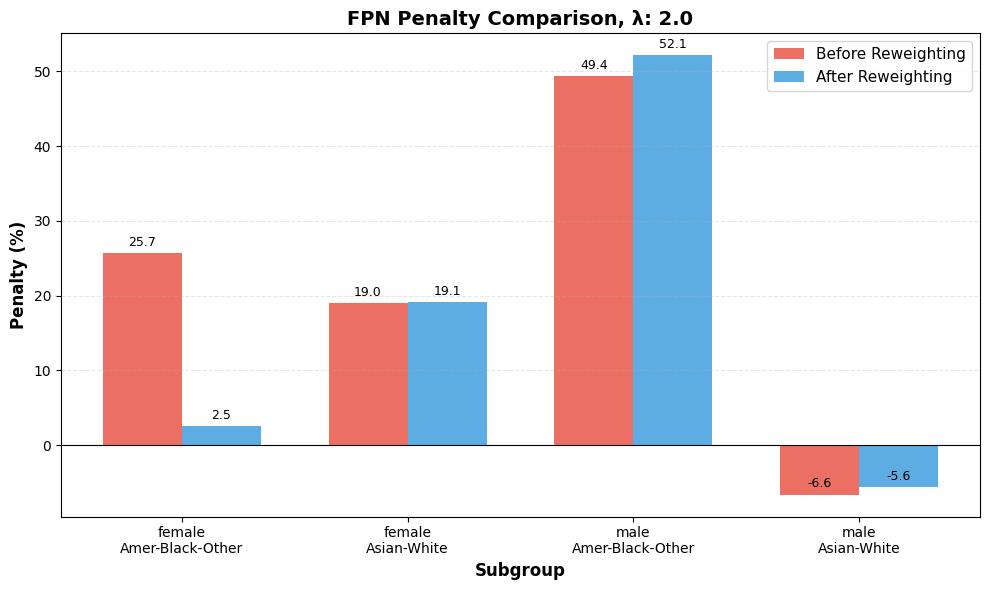


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 2.54 (Δ = -23.17)
  female-Asian-White: 18.99 → 19.11 (Δ = +0.12)
  male-Amer-Black-Other: 49.35 → 52.14 (Δ = +2.79)
  male-Asian-White: -6.60 → -5.62 (Δ = +0.99)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2043,  206],
       [ 328,  698]])}
{np.int64(1): array([[2965,  220],
       [ 371,  759]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1145,   21],
       [  74,   83]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1825,  194],
       [ 304,  669]]), '10': array([[224,   6],
       [ 31,  22]])}


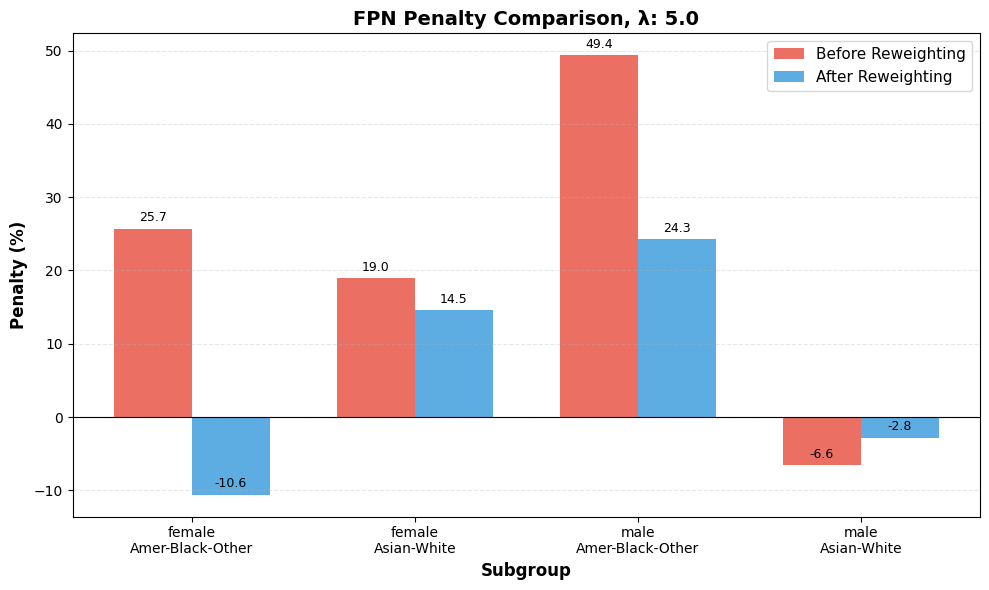


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → -10.58 (Δ = -36.29)
  female-Asian-White: 18.99 → 14.54 (Δ = -4.45)
  male-Amer-Black-Other: 49.35 → 24.25 (Δ = -25.10)
  male-Asian-White: -6.60 → -2.82 (Δ = +3.79)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 3.6688379364252213, '10': 5.341216216216215, '11': 0.49321238464203554}
{np.int64(0): array([[1406,   24],
       [  87,   93]]), np.int64(1): array([[2050,  199],
       [ 343,  683]])}
{np.int64(1): array([[2974,  211],
       [ 386,  744]]), np.int64(0): array([[482,  12],
       [ 44,  32]])}
{'01': array([[1146,   20],
       [  75,   82]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1818,  201],
       [ 293,  680]]), '10': array([[224,   6],
       [ 31,  22]])}


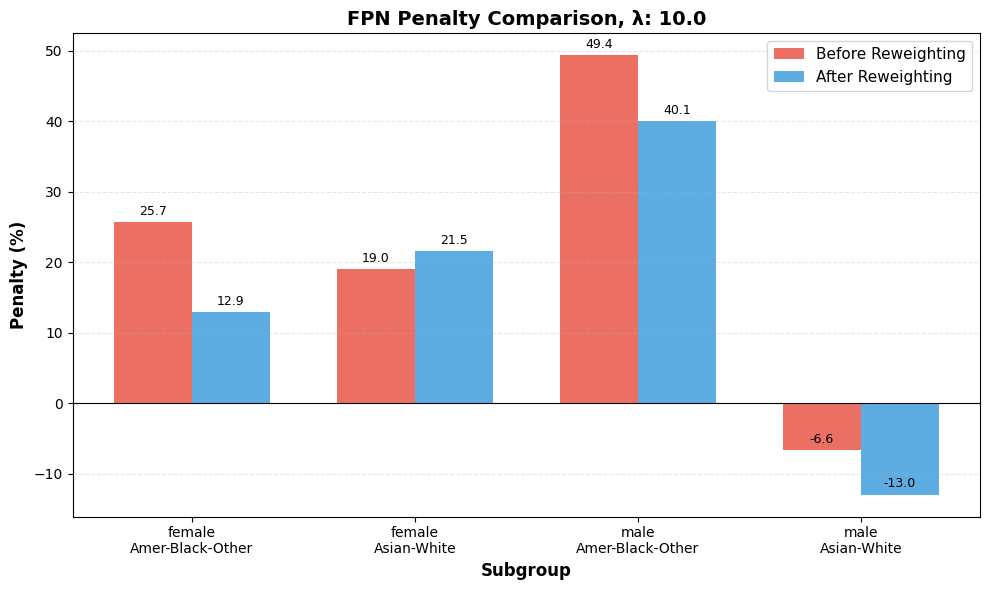


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 12.89 (Δ = -12.82)
  female-Asian-White: 18.99 → 21.53 (Δ = +2.54)
  male-Amer-Black-Other: 49.35 → 40.08 (Δ = -9.28)
  male-Asian-White: -6.60 → -12.97 (Δ = -6.37)
------------------------------------------------------------


In [80]:
for l in lambdas:
    penalties_ontest_after_reweighting = {}

    weights_notsized = compute_weights_notsized(l, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN']= compute_penalties_after_reweighting(weights_notsized, 'FPN', dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

    plot_penalty_comparison_all_individual(['FPN'], penalties_ontest, penalties_ontest_after_reweighting, 
                                            sensible_attribute, mapping, l)

In [81]:
if ALL_FM_L_NOTSIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_notsized = compute_weights_notsized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                    sensible_attribute, mapping, l)

In [82]:
if SIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

In [83]:
if SIZED == 1 and ALL_FM_L_SIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

Training samples: 22792, Unique weights per group: {'00': 0.5854166666666667, '01': 1.1334418968212612, '10': 1.2170608108108107, '11': 0.9746606192321018}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2047,  202],
       [ 334,  692]])}
{np.int64(1): array([[2967,  218],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 46,  30]])}
{'01': array([[1136,   30],
       [  71,   86]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1812,  207],
       [ 286,  687]]), '10': array([[225,   5],
       [ 33,  20]])}
Training samples: 22792, Unique weights per group: {'00': 0.17083333333333328, '01': 1.2668837936425221, '10': 1.4341216216216215, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2045,  204],
       [ 332,  694]])}
{np.int64(1): array([[2965,  220],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  76, 

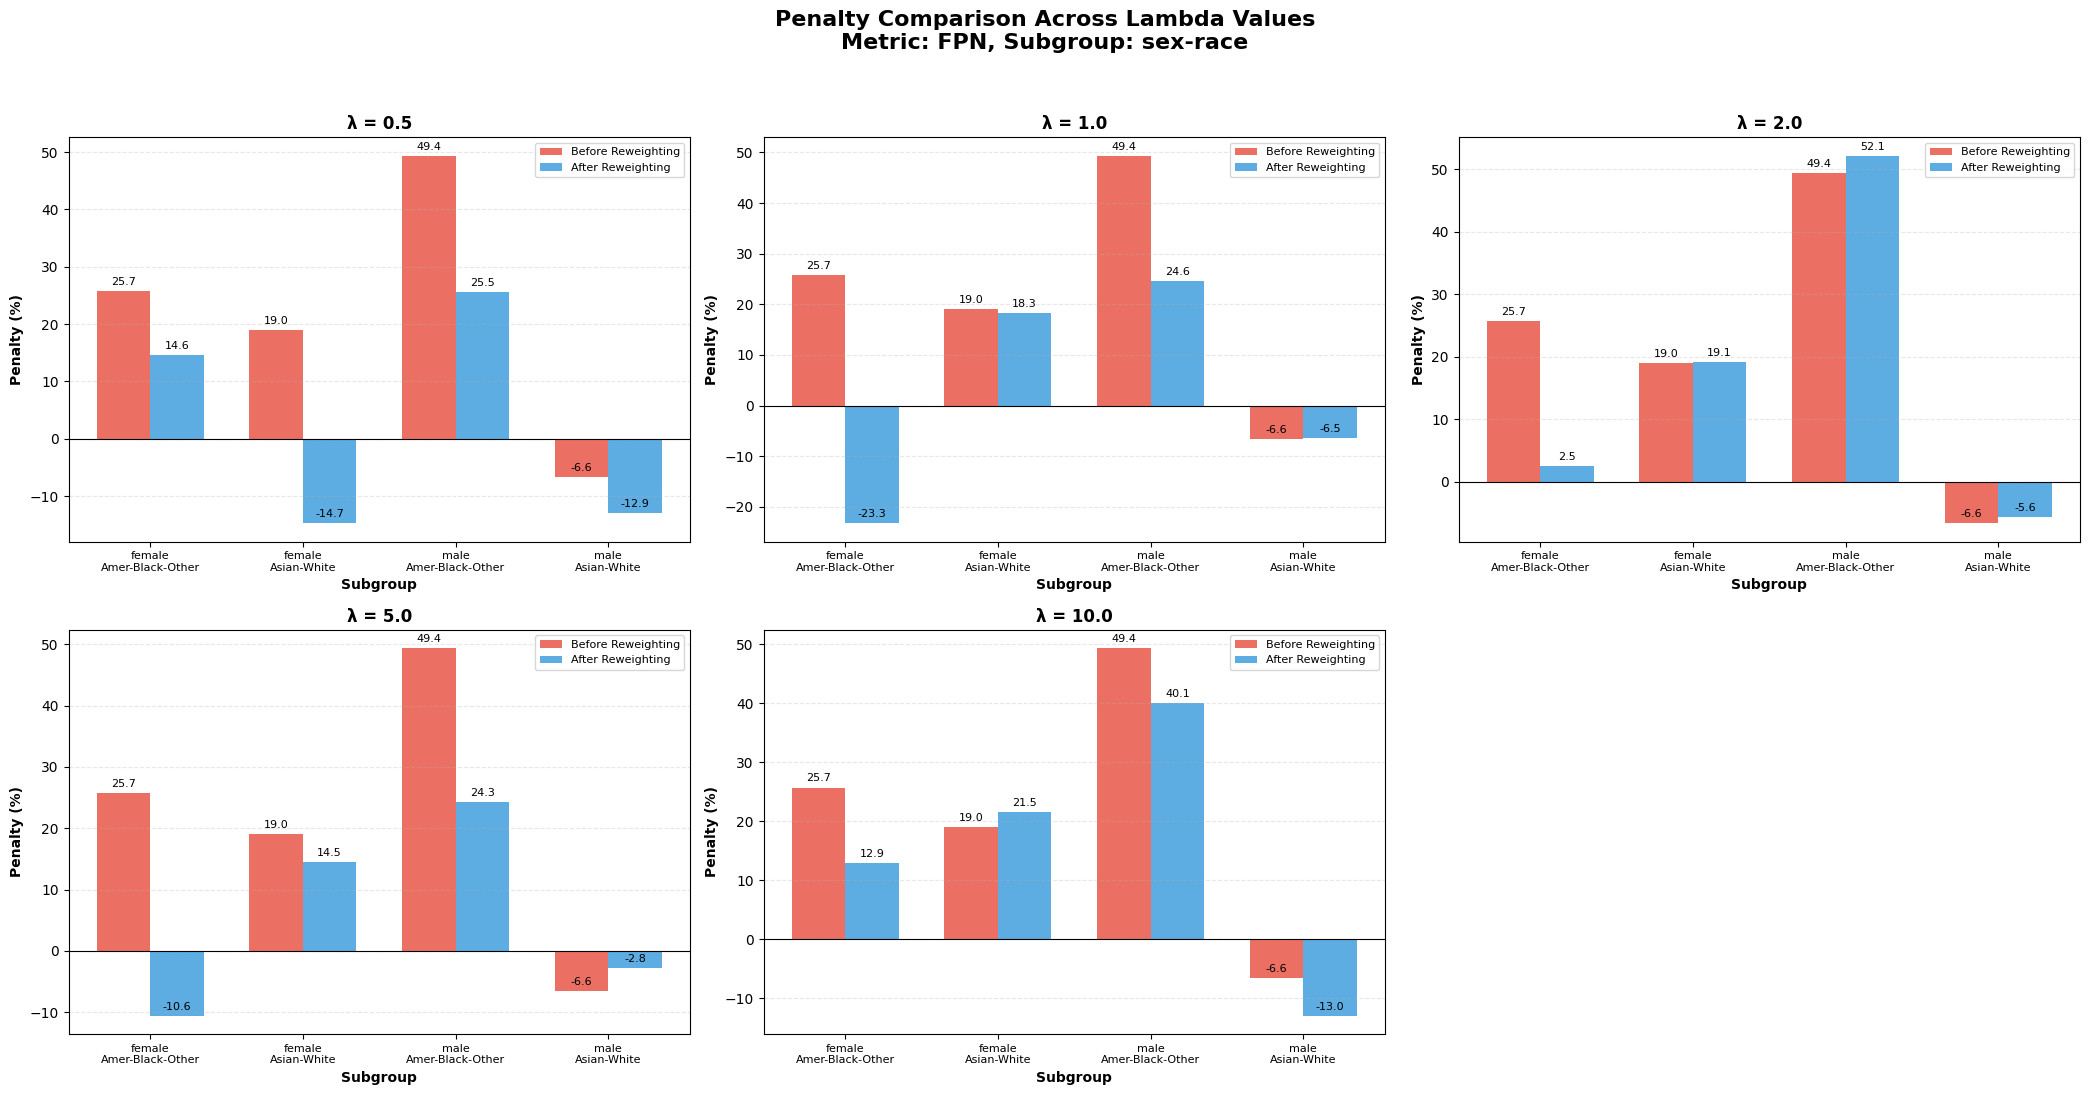

In [84]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_notsized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

Training samples: 22792, Unique weights per group: {'00': 0.9628189721146028, '01': 1.0599521565428853, '10': 1.0208993835635032, '11': 0.9746606192321018}
{np.int64(0): array([[1407,   23],
       [  88,   92]]), np.int64(1): array([[2046,  203],
       [ 331,  695]])}
{np.int64(1): array([[2967,  218],
       [ 373,  757]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1146,   20],
       [  77,   80]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1824,  195],
       [ 304,  669]]), '10': array([[225,   5],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 0.9256379442292055, '01': 1.1199043130857709, '10': 1.0417987671270064, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  92,   88]]), np.int64(1): array([[2048,  201],
       [ 336,  690]])}
{np.int64(1): array([[2969,  216],
       [ 382,  748]]), np.int64(0): array([[487,   7],
       [ 46,  30]])}
{'01': array([[1135,   31],
       [  70,  

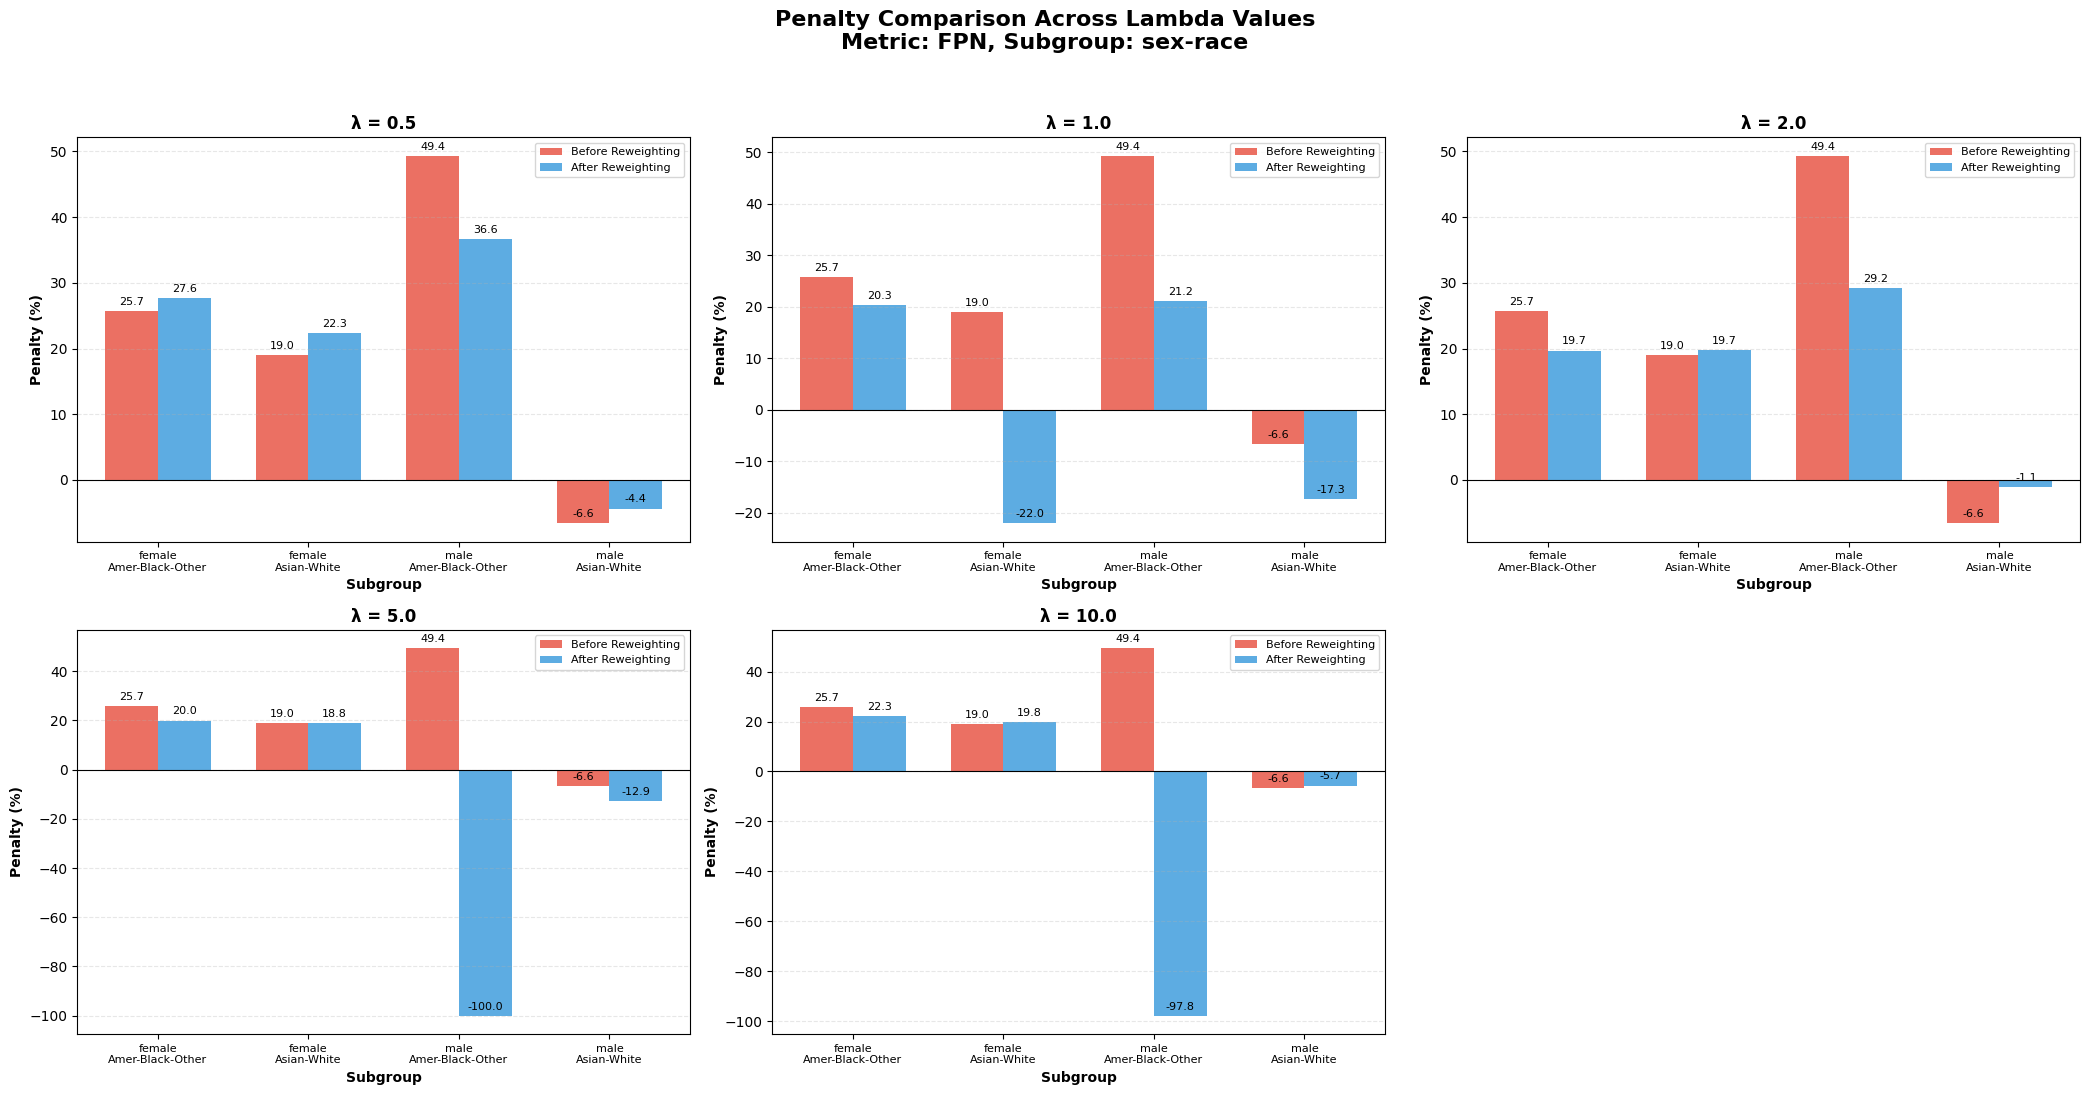

In [85]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_sized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

# KFOLD

In [86]:
# Run K-fold penalty computation
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
penalties_kfold_avg, penalties_per_fold = compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5)

K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K=5)
Train+Val samples: 27676
Test samples (held out): 4885

--- Fold 1/5 ---
  Val distribution: {'00': 276, '01': 1619, '10': 300, '11': 3341}

--- Fold 2/5 ---
  Val distribution: {'00': 306, '01': 1472, '10': 341, '11': 3416}

--- Fold 3/5 ---
  Val distribution: {'00': 317, '01': 1545, '10': 361, '11': 3312}

--- Fold 4/5 ---
  Val distribution: {'00': 310, '01': 1500, '10': 339, '11': 3386}

--- Fold 5/5 ---
  Val distribution: {'00': 287, '01': 1529, '10': 299, '11': 3420}

AVERAGED PENALTIES (across 5 folds)

FPN:
  00: avg=+12.97%, std=55.40, folds=['48.3', '-17.0', '-7.2', '100.0', '-59.3']
  01: avg=+15.32%, std=8.68, folds=['17.4', '5.6', '7.7', '15.7', '30.1']
  10: avg=+16.93%, std=22.21, folds=['-11.1', '42.6', '31.5', '30.1', '-8.3']
  11: avg=-4.12%, std=0.90, folds=['-3.5', '-3.7', '-3.9', '-5.9', '-3.6']

PPE:
  00: avg=+57.54%, std=27.58, folds=['67.8', '59.6', '44.0', '100.0', '16.2']
  01: avg=+30.29%, std=6.66, fold

In [88]:
# Compute penalties on test set after K-fold reweighting
penalties_ontest_after_kfold = {}
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, metric)
    penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, metric, dataset_path, sensible_attribute, X_test, y_test, fair_metrics, mapping, target_variable_labels)
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting
    
print("\nPenalties after K-fold reweighting computed for all metrics.")

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.6482908903961535), '01': np.float64(1.7659501778535382), '10': np.float64(1.8464121705831142), '11': np.float64(0.7940159556548778)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.8768973824712263), '01': np.float64(2.5143711324156217), '10': np.float64(1.046269285155348), '11': 0.01}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.718604319244079), '01': np.float64(2.2733649802827083), '10': np.float64(1.2635069086732622), '11': np.float64(0.15248187352621922)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.0038850442000484), '01': np.float64(0.8656303230053926), '10': np.float64(0.8858241104195381), '11': np.float64(1.0178114724140443)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.8025313608926784), '01': np.float64(0.7780072641178941), '10': np.float64(0.9155857374234886), '11': np.float64(1.1264524927854598

In [100]:
penalties_after_by_lambda

{0.5: {'00': 23.05900621118012,
  '01': 16.403190901994634,
  '10': 31.274131274131264,
  '11': -6.152386512917832},
 1.0: {'00': 28.192934782608692,
  '01': 16.55417251051894,
  '10': 26.35041551246537,
  '11': -5.9719377035402825},
 2.0: {'00': 22.16614906832298,
  '01': 16.737416238117504,
  '10': 32.31283951505557,
  '11': -6.278251993620419},
 5.0: {'00': 28.192934782608692,
  '01': 16.705382187938294,
  '10': 26.463737093930995,
  '11': -6.04479821198671},
 10.0: {'00': 100.0,
  '01': 12.580629633195345,
  '10': -22.51320422535211,
  '11': -3.7317768543268377}}

In [ ]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_sized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.0648290890396153), '01': np.float64(1.0765950177853538), '10': np.float64(1.0846412170583115), '11': np.float64(0.9794015955654878)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.1296581780792307), '01': np.float64(1.1531900355707076), '10': np.float64(1.1692824341166228), '11': np.float64(0.9588031911309756)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.2593163561584615), '01': np.float64(1.3063800711414153), '10': np.float64(1.3385648682332456), '11': np.float64(0.9176063822619511)}


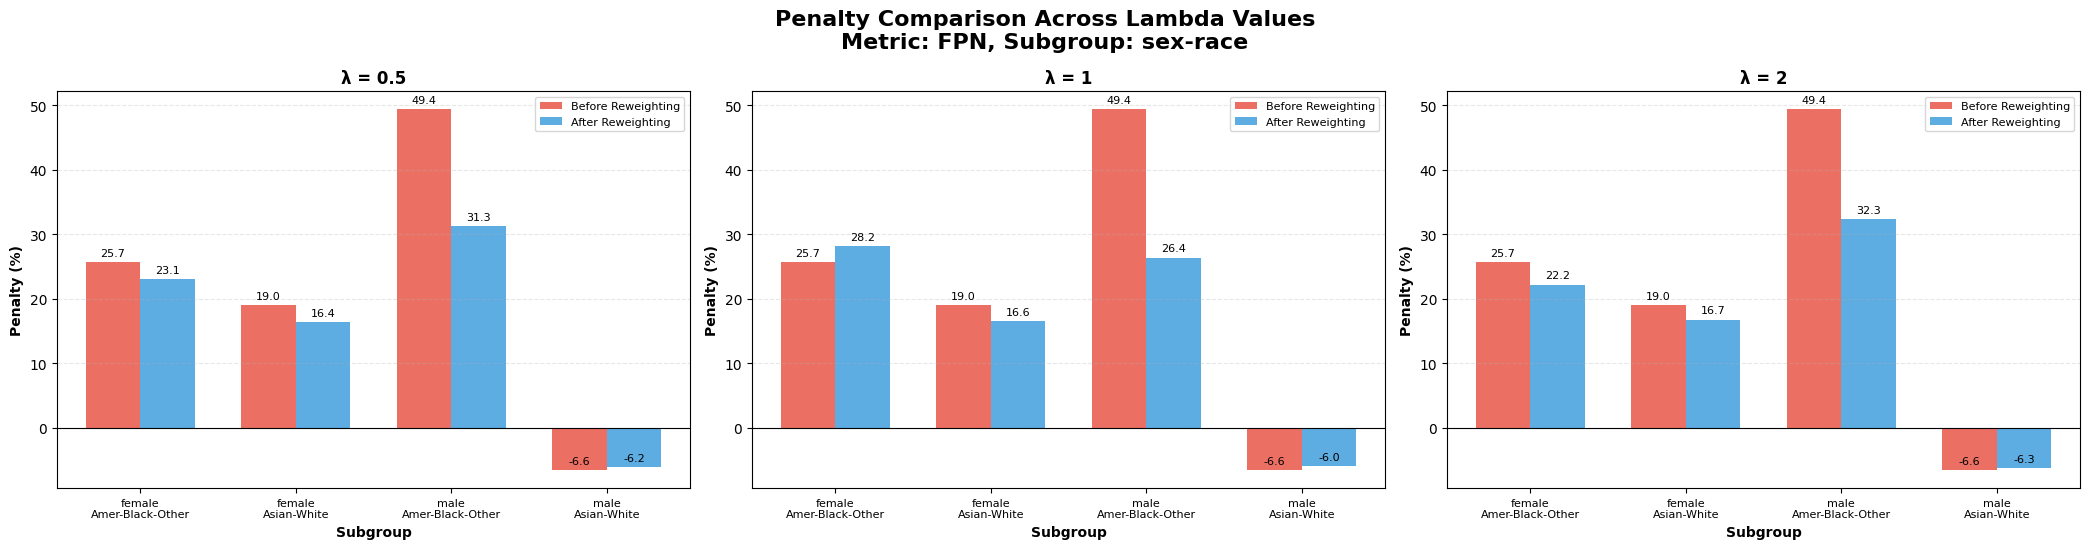

In [106]:
# First, compute penalties for each lambda
penalties_after_by_lambda_kfold = {}
lambdas = [0.5, 1, 2]

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']

for l in lambdas: 
    penalties_ontest_after_reweighting = {}
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(l, 'FPN')
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, 'FPN', dataset_path, sensible_attribute, X_test, y_test, fair_metrics, mapping, target_variable_labels)
    penalties_after_by_lambda_kfold[l] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda_kfold, 
                            sensible_attribute, mapping)

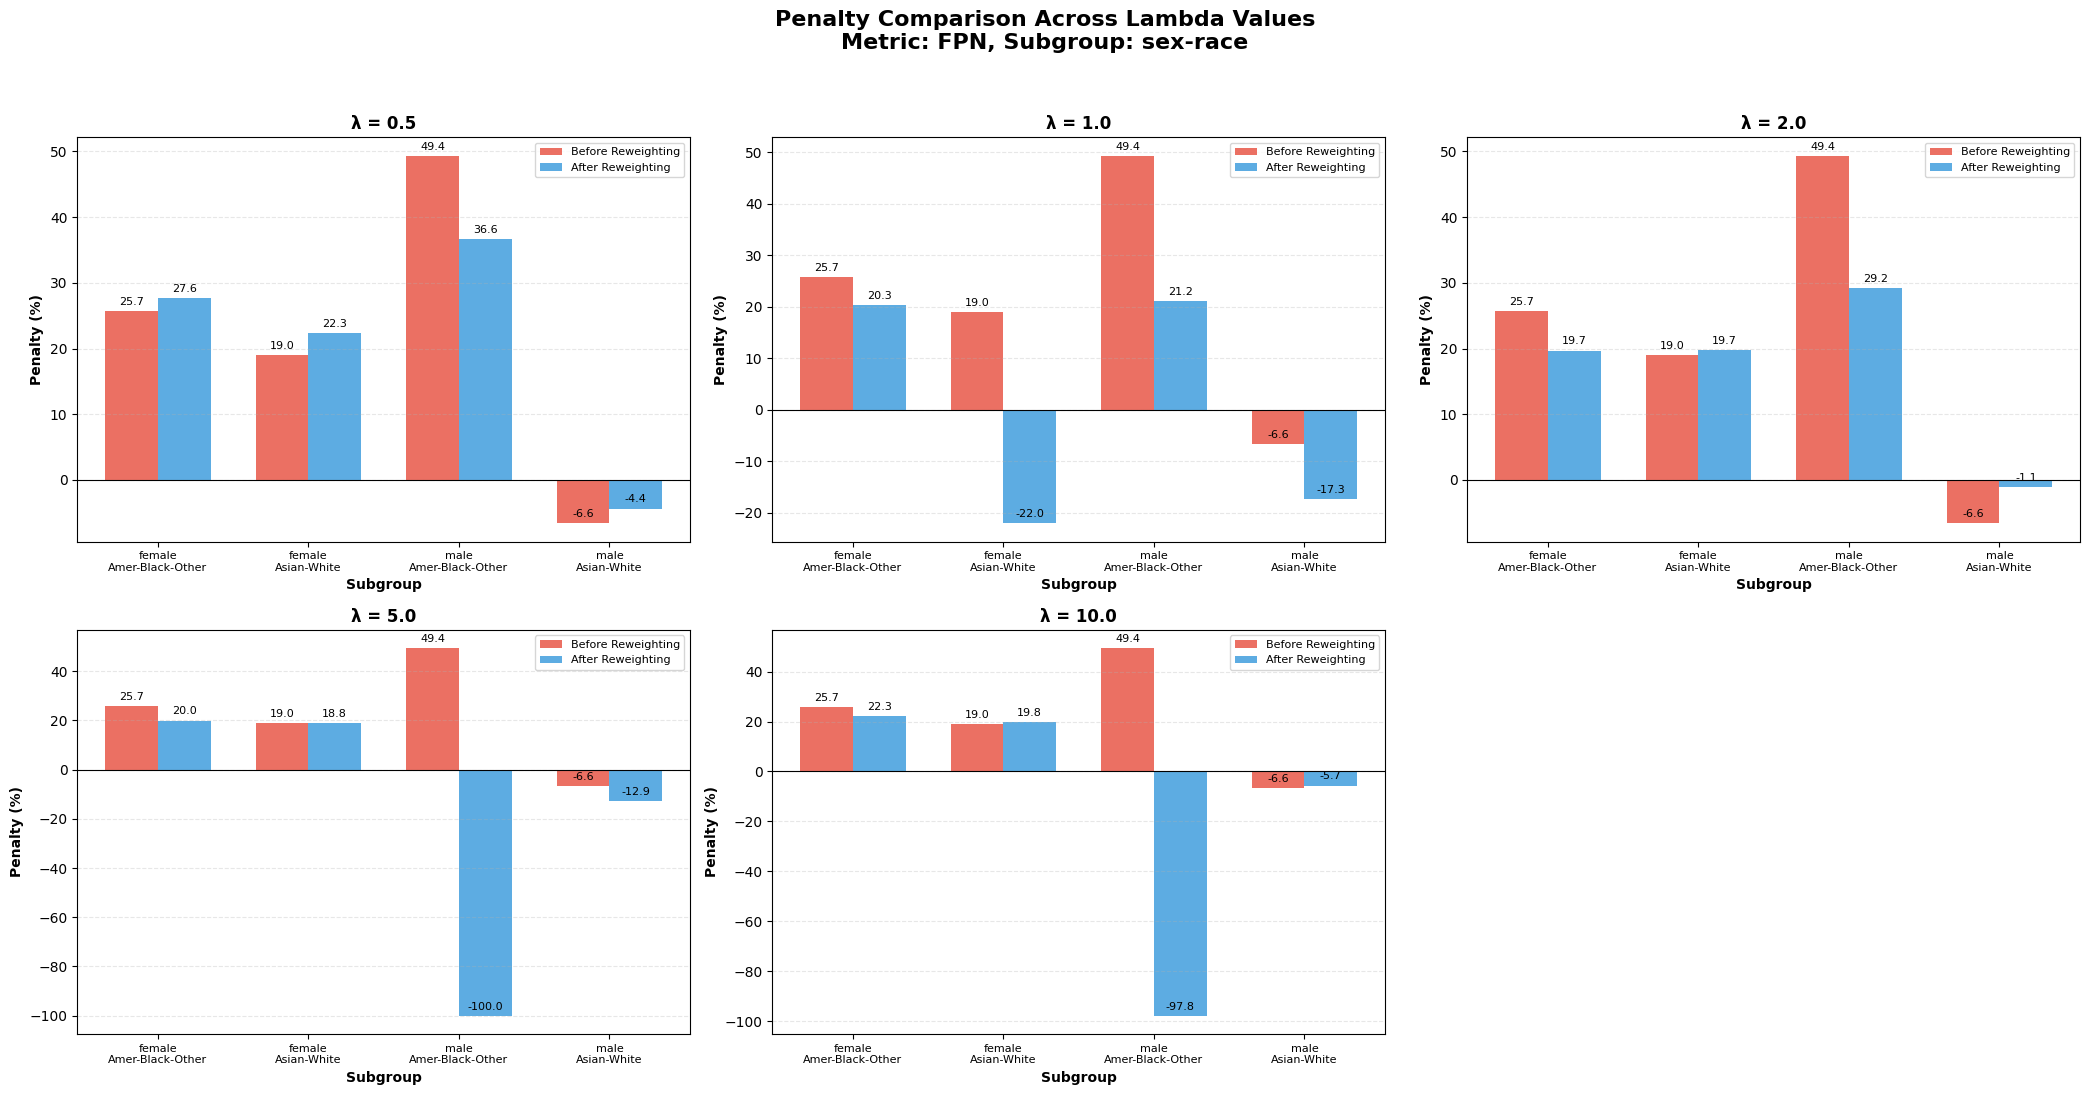

In [90]:
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda_kfold, sensible_attribute, mapping)

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.6482908903961535), '01': np.float64(1.7659501778535382), '10': np.float64(1.8464121705831142), '11': np.float64(0.7940159556548778)}


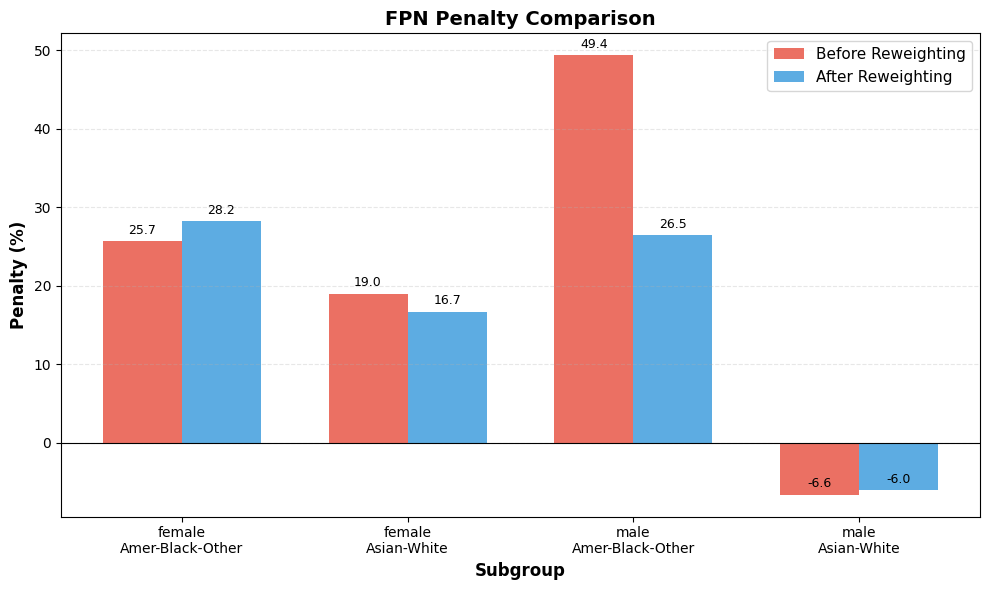


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 28.19 (Δ = +2.48)
  female-Asian-White: 18.99 → 16.71 (Δ = -2.29)
  male-Amer-Black-Other: 49.35 → 26.46 (Δ = -22.89)
  male-Asian-White: -6.60 → -6.04 (Δ = +0.56)
------------------------------------------------------------


In [ ]:
weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, 'FPN')
penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(weights_kfold, X_trainval, y_trainval, 'FPN')
fair_metrics=['FPN']
plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_kfold, sensible_attribute, mapping)